# ESS.112 and telescope elevation study


## References

- [Times Square: Image Quality Nightly Report: IQ, AOS, and EAS](https://usdf-rsp.slac.stanford.edu/times-square/github/lsst-sitcom/ts_aos_analysis/notebooks/nightly_report/nightly_report_aos_eas?dayobs=20250827&ts_hide_code=1)
- [GitHub: Image Quality Nightly Report: IQ, AOS, and EAS](https://github.com/lsst-sitcom/ts_aos_analysis/blob/develop/notebooks/nightly_report/nightly_report_aos_eas.ipynb)
- [SITCOM-2212 Investigate possible correlation between temperature from ESS:112 and telescope elevation](https://rubinobs.atlassian.net/browse/SITCOM-2212)
- [SITCOM-2079 Traceback and model for the available temperature sensors during ComCam](https://rubinobs.atlassian.net/browse/SITCOM-2079)
- [LTS-192 M2 Electronics Design Document](https://docushare.lsstcorp.org/docushare/dsweb/Get/Document-54702/LTS-192%20M2%20Electronics%20Design%20Document.pdf)


## Introduction

I expect this notebook to be a little different from other's I have been working on.  
Instead of being a notebook where you simply execute all the cells,  
I expect it to be more like a study.  
Let's see how it goes.

The main challenge with this study is that the temperatures are different every day.  
So we cannot make a simple and direct correlation between the temperature measured on ESS:112 and the telescope elevation.  
Let me start then my analysis be querying the telemetry displayed in [Nightly Report EAS in Times Square].  
Then, I will consider the data from a full day obs for now.  
I will create a correlation matrix using binned data with the min and max values groupy by each half second.
  
[Nightly Report EAS in Times Square]: https://usdf-rsp.slac.stanford.edu/times-square/github/lsst-sitcom/ts_aos_analysis/notebooks/nightly_report/nightly_report_aos_eas?dayobs=20250827&ts_hide_code=1


## Initial Dataset

As mentioned above, let's start with a single day obs and let's start with the telemetry in [Nightly Report EAS in Times Square].

I started some analysis and the temperatures during the day pollute lots of what we are looking for.  
So, since I want to make my life easy, I will start my analysis looking for nights where we were totally on sky.  
After that, I will select the timestamps between the end and the beginning of astronomical twilights.  
This is to minimize the effects of temperature changes in my analysis.

In [67]:
# Let's use this for single-day analysis
day_obs = 20250827


# And this for ranged analysis
start_day_obs = 20250501
end_day_obs = 20250901

In [68]:
import asyncio
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz

from astropy.coordinates import get_sun, AltAz, EarthLocation
from astropy.time import Time, TimeDelta

from lsst_efd_client import EfdClient
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)

In [69]:
# Create an instance of the EfdClient
efd_client = makeEfdClient()

# Gather the start and end time of our analysis
start_time = getDayObsStartTime(day_obs)
end_time = getDayObsEndTime(day_obs)

print(f"This initial analysis will contain data from:\n"
      f"  {start_time} to {end_time}.\n")

This initial analysis will contain data from:
  2025-08-27 12:00:00 to 2025-08-28 12:00:00.



### Select nights fully on sky

I have been going back and forth in this analysis.  
As I look at the plots, I believe it is hard to evaluate what affects what if we include the Sun in the equation.  
I want to consider the scenario where the dome is partially thermalized to make analysis easier.  

For this work, I will use the [ConsDB_visits_metadata] notebook in Times Square.  
The code seems to have exactly what I need. 

The cells bellow require the [lsst-sims/rubin_nights] module, which seems not to be in the standard stack.  
The first of them will install it using PIP. 
You can either comment it out or simply skip it if you are sure you have it running.

[ConsDB_visits_metadata]: https://usdf-rsp.slac.stanford.edu/times-square/github/lsst/schedview_notebooks/nightly/ConsDB_visits_metadata?day_obs_min=20250620&day_obs_max=20250820&instrument=lsstcam&ts_hide_code=1
[lsst-sims/rubin_nights]: https://github.com/lsst-sims/rubin_nights

In [70]:
import os

if os.getenv("EXTERNAL_INSTANCE_URL") is not None:
    print("updating rubin_nights\n")
    !pip install --user --upgrade git+https://github.com/lsst-sims/rubin_nights.git  --no-deps  > /dev/null 2>&1

updating rubin_nights



In [71]:
import logging
from rubin_nights import connections
from rubin_nights.observatory_status import get_dome_open_close


# Try to silence the annoying logs 
logging.getLogger("httpx").setLevel(logging.CRITICAL)
logging.getLogger("rubin_nights.connections").setLevel(logging.CRITICAL)

All the functions and classes in [lsst-sims/rubin_nights] use a sync version of the EFD client.  
Since I am lazy and I don't want to rewrite the code, I will create an instance of this version and use it.

In [34]:
sync_efd_client = connections.get_clients()['efd']

We can now finally get the dome status.  
In this case, our data frame will have a single row.  
But, in future analysis, we will have several rows. 

In [44]:
dome_status = get_dome_open_close(
    getDayObsStartTime(20250501), 
    getDayObsEndTime(20250901), 
    sync_efd_client
)

dome_status.head()

,day_obs,open_time,close_time,open_hours
0,20250501,2025-05-01 22:23:34.738059,2025-05-02 10:10:25.586367,11.780791
1,20250502,2025-05-02 22:11:25.279400,2025-05-03 09:35:32.826047,11.402096
2,20250503,2025-05-03 22:22:12.551599,2025-05-04 09:47:10.912461,11.416211
3,20250504,2025-05-04 22:20:34.132350,2025-05-05 09:49:01.435237,11.474251
4,20250505,2025-05-06 00:21:04.706085,2025-05-06 09:51:13.207688,9.502362


Cool! Now we can select the `day_obs` that have more than ten hours per night.  
This is a good start. We can think of a better criteria later.

In [106]:
long_nights = dome_status[dome_status.open_hours >= 8]
long_nights.head(5)

,day_obs,open_time,close_time,open_hours
0,20250501,2025-05-01 22:23:34.738059,2025-05-02 10:10:25.586367,11.780791
1,20250502,2025-05-02 22:11:25.279400,2025-05-03 09:35:32.826047,11.402096
2,20250503,2025-05-03 22:22:12.551599,2025-05-04 09:47:10.912461,11.416211
3,20250504,2025-05-04 22:20:34.132350,2025-05-05 09:49:01.435237,11.474251
4,20250505,2025-05-06 00:21:04.706085,2025-05-06 09:51:13.207688,9.502362


### Select night time

Now, for each night, we want to select a time when we think that the temperature will be stable already.  
A good quick-and-dirt time window that we can use to select is the end and the beginning of the astronomical twilight.  
Luckly, the [Times Square: Image Quality Nightly Report: IQ, AOS, and EAS](https://usdf-rsp.slac.stanford.edu/times-square/github/lsst-sitcom/ts_aos_analysis/notebooks/nightly_report/nightly_report_aos_eas?dayobs=20250827&ts_hide_code=1) notebook has a function that help me with it easily.

In [45]:
def find_sun_altitude_crossings(start_time: Time, end_time: Time, altitude_deg: float, rising: bool) -> list:
    """
    Return a list of localized datetimes when the sun crosses a given altitude
    (e.g., -18 for twilight, 0 for sunrise/sunset) between start_time and end_time.

    Parameters
    ----------
    start_time : Time
        Astropy start time.
    end_time : Time
        Astropy end time.
    altitude_deg : float
        Target sun altitude in degrees.
    rising : bool
        True for rising (upward crossing), False for setting (downward).

    Returns
    -------
    list[datetime]
        Localized CLT datetimes when the sun crosses the given altitude.
    """
    location = EarthLocation.of_site("Cerro Pachon")
    clt = pytz.timezone("America/Santiago")

    step_seconds = 60
    n_steps = int((end_time - start_time).sec / step_seconds) + 1
    times = start_time + TimeDelta(np.arange(n_steps) * step_seconds, format='sec')

    altaz = AltAz(obstime=times, location=location)
    sun_alt = get_sun(times).transform_to(altaz).alt.deg
    times_clt = times.to_datetime(timezone=clt)

    crossings = []
    for i in range(1, len(sun_alt)):
        prev_alt = sun_alt[i - 1]
        curr_alt = sun_alt[i]
        if rising and prev_alt < altitude_deg <= curr_alt:
            crossings.append(times_clt[i])
        elif not rising and prev_alt > altitude_deg >= curr_alt:
            crossings.append(times_clt[i])

    return crossings

In [74]:
twilight_ends = find_sun_altitude_crossings(start_time, end_time, altitude_deg=-18, rising=False)[0]
twilight_starts = find_sun_altitude_crossings(start_time, end_time, altitude_deg=-18, rising=True)[0]


print(f"The end of the astronomical twilight on day_obs = {day_obs} was at {twilight_ends}.")
print(f"The begin of the astronomical twilight on day_obs = {day_obs} was at {twilight_starts}.")

The end of the astronomical twilight on day_obs = 20250827 was at 2025-08-27 19:46:00-04:00.
The begin of the astronomical twilight on day_obs = 20250827 was at 2025-08-28 05:43:00-04:00.


<br>
Alright, now let's complement our dataframe with some new columns that will be useful!

Arg! For whatever reason, I need to have the code in the cells below split and ron cell-by-cell. 

In [119]:
long_nights.loc[:, "start_time"] = long_nights["day_obs"].apply(
    getDayObsStartTime)

In [120]:
long_nights.loc[:, "end_time"] = long_nights["day_obs"].apply(
    getDayObsEndTime)

In [122]:
long_nights.loc[:, "end_of_astronomical_twilight"] = long_nights.apply(
    lambda row: find_sun_altitude_crossings(
        row['start_time'], row['end_time'], altitude_deg=-18, rising=False)[0], axis=1)

In [123]:
long_nights.loc[:, "begin_of_astronomical_twilight"] = long_nights.apply(
    lambda row: find_sun_altitude_crossings(
        row['start_time'], row['end_time'], altitude_deg=-18, rising=True)[0], axis=1)

SettingWithCopyError: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

### ESS:112 M2; RPi with sticker 1

The [ESS:112](https://github.com/lsst-ts/ts_config_ocs/blob/49e7dd64b62415685f28b8bc2f179a3633c05059/ESS/v8/_init.yaml#L227) is one of our favorite sensors that we use to estimate the temperature inside the dome.  
This is the sensor in which we believe that is measuring temperature gradients depending on the elevation angle. 

Previous analysis showed that the average sampling is about 1.4 seconds.  
This means that we probably don't need to subsample this dataset.  
Querying 24h of data takes around 6 seconds.

In [53]:
ess_112_df = await efd_client.select_time_series(
    topic_name="lsst.sal.ESS.temperature", 
    fields=["temperatureItem0"], 
    start=start_time, 
    end=end_time, 
    index=112
)

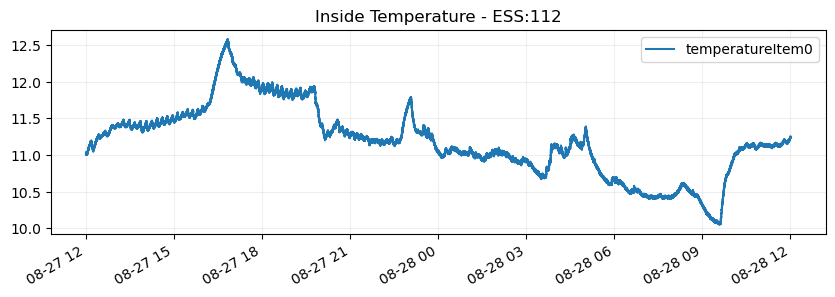

In [54]:
ess_112_df.plot(title="Inside Temperature - ESS:112", figsize=(10, 3))
plt.grid(":", alpha=0.2)

We can see lots of spikes in this data.  
This is probably what Elana is looking for. 

Part of the analysis is to look for correlation between these temperatures and the elevation angle.  
We can plot both together to see if the peaks have correlation with any elevation change.  
Let's do this.

In [55]:
query = efd_client.build_time_range_query(
    "lsst.sal.MTMount.elevation",
    ["mean(actualPosition)"],
    start_time,
    end_time,
) + "GROUP BY time(30s)"

elevation_df = await efd_client.influx_client.query(query)

Since we now have a function defined above that allows us to easily find the end and beginng of the astronomical twilight,  
let's plot them together with everything else to see if that reagion is a good candidate for the thermalized region.

In [56]:
twilight_ends = find_sun_altitude_crossings(start_time, end_time, altitude_deg=-18, rising=False)
twilight_starts = find_sun_altitude_crossings(start_time, end_time, altitude_deg=-18, rising=True)

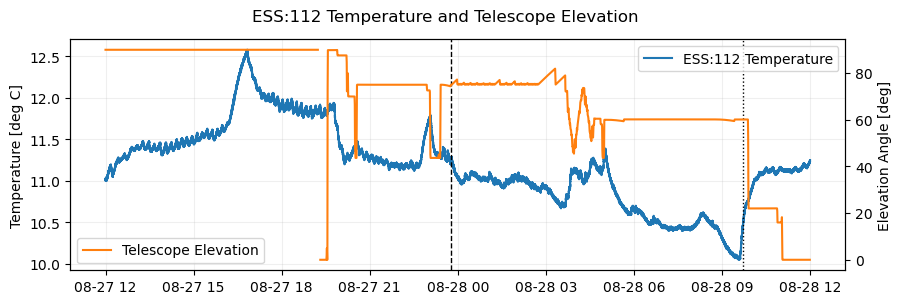

In [59]:
fig, ax = plt.subplots(figsize=(10, 3))

fig.suptitle("ESS:112 Temperature and Telescope Elevation")
ax.plot(ess_112_df, color="C0", label="ESS:112 Temperature")
ax.grid(":", alpha=0.2)
ax.set_ylabel("Temperature [deg C]")
ax.legend(loc="upper right")

ax.axvline(twilight_ends[0], color="black", linestyle="--", linewidth=1, label="Twilight End")
ax.axvline(twilight_starts[0], color="black", linestyle=":", linewidth=1, label="Twilight End")

ax2 = ax.twinx()
ax2.plot(elevation_df, color="C1", label="Telescope Elevation")
ax2.set_ylabel("Elevation Angle [deg]")
ax2.legend(loc="lower left")

plt.show()

Yes, it seems quite fair. I can add these same lines to the other plots below.

### ESS:301 Weather Tower

[ESS:301] can give us some reference about the environment conditions.  
We know, by experience, that the temperature inside and outsite the dome can be very different.  
I might drop this one later if we decide to focus more in our analysis.  
Remember that the goal here is to try to identify a vertical gradient inside the dome.

The sampling average here is about 3.8 seconds.  
You can easily see that we will have to do some data-processing if we want to do our correlation matrix. 

[ESS:301]: https://github.com/lsst-ts/ts_config_ocs/blob/49e7dd64b62415685f28b8bc2f179a3633c05059/ESS/v8/_init.yaml#L480

In [61]:
ess_301_df = await efd_client.select_time_series(
    topic_name="lsst.sal.ESS.temperature", 
    fields=["temperatureItem0"], 
    start=start_time, 
    end=end_time, 
    index=301
)

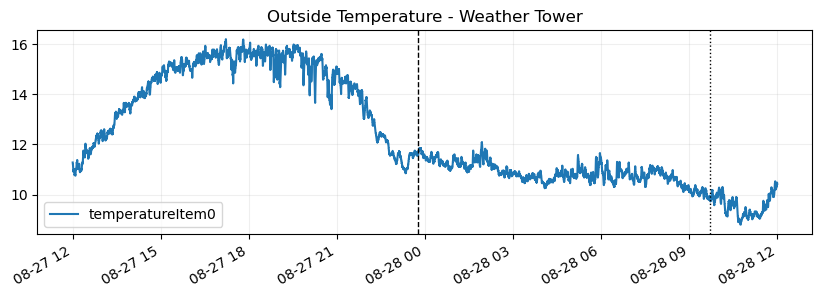

In [62]:
ess_301_df.plot(title="Outside Temperature - Weather Tower", figsize=(10, 3))
plt.axvline(twilight_ends[0], color="black", linestyle="--", linewidth=1, label="Twilight End")
plt.axvline(twilight_starts[0], color="black", linestyle=":", linewidth=1, label="Twilight End")
plt.grid(":", alpha=0.2)

Here you can clearly see the effect of the sun in the temperature outside.  
There is some fluctuation, but the overal trend is very clear.  
This is typical of a dataset that is more robust and insensitive to other parameters, as it should be.

### MTM2.temperature

The MTM2 CSC have internal temperature sensors as well.  
The [MTM2.temperature] contains 12 channels corresponding to 12 sensors inside the cell.  
Based on a quick conversation with Elana, it seems that column `ring5` corresponds to sensor 
that is mounted temporarily outside the m2 cell.  
This is why we can also use it to track ambient temperature. 

The sampling for this dataset has an average of 0.05 seconds.  
This is much more than what we need.  
A query containing 24h of telemetry can take almost five minutes to be completed.  
Considering the time scale of the telemetry above, 
and considering that we are still in an exploratory phase, let's do a sampling of half minute.

[MTM2.temperature]: https://ts-xml.lsst.io/sal_interfaces/MTM2.html#temperature

In [63]:
# First, let's build the query
query = efd_client.build_time_range_query(
    "lsst.sal.MTM2.temperature",
    [f"mean(ring{i}) as mean_ring_{i}" for i in range(12)],
    start_time,
    end_time,
) + "GROUP BY time(30s)"

# And then we query it, this takes a long time
mtm2_temp_df = await efd_client.influx_client.query(query)

<br>
Just because I am curious, let's have a look at the data considering all the channels.

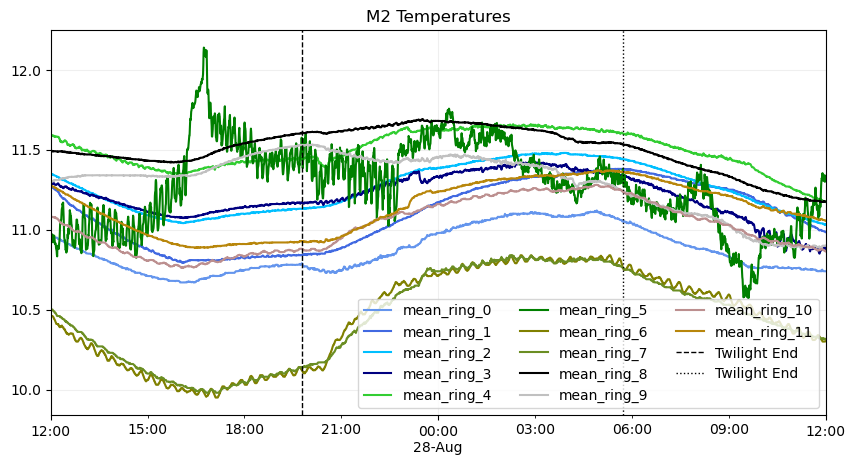

In [65]:
colors = ["cornflowerblue", "royalblue", "deepskyblue", "navy",
          "limegreen", "green", "olive", "olivedrab",
          "black", "silver", "rosybrown", "darkgoldenrod"]
mtm2_temp_df.plot(title="M2 Temperatures", figsize=(10, 5), color=colors)
plt.axvline(twilight_ends[0], color="black", linestyle="--", linewidth=1, label="Twilight End")
plt.axvline(twilight_starts[0], color="black", linestyle=":", linewidth=1, label="Twilight End")
plt.legend(ncols=3, loc="lower right")
plt.grid(":", alpha=0.2)

It calls my attention that `ring5` is the topic that we are using.  
It seems sensitive to "something" else. 

All the other temperature channels have a clear trend.  
Some of them show some oscillation (like ring 6 and 